<a href="https://colab.research.google.com/github/shivansh2310/Quantitative-Portfolio-Management/blob/main/Data_Pipeline_%26_Target_Engineering_(Chapters_1%E2%80%932).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In traditional finance, analysts try to predict whether a stock will go "up" or "down" (predicting raw returns). In Statistical Arbitrage, predicting raw returns is considered toxic.

If you build a Machine Learning model to predict raw returns, 90% of what it learns is just "Market Beta." If the S&P 500 goes up 2%, almost every stock goes up. If your ML model predicts AAPL will be up 1.5% on a day the market is up 2.5%, your model is actually predicting underperformance, but a raw return target will label it as a "positive" move.

To train an ML model to find true edge, we must feed it Neutralized Idiosyncratic Returns.

### A. The Target Variable ($Y$)

We are predicting the future. Typically, we want to predict the 1-day or 5-day forward return.

  * $Y_t = R_{t+1}$ (The return from today's close to tomorrow's close).

### B. Cross-Sectional Neutralization

We must strip the market and the sector out of $Y_t$ before the ML model ever sees it.

* Step 1: Subtract the cross-sectional mean (the Market). If the average return of all stocks today is 1%, subtract 1% from every stock.

* Step 2: Subtract the Sector mean. If Tech stocks averaged 2% today, subtract an additional 1% from all Tech stocks.

* The Result: You are left with pure idiosyncratic residual returns. This is your true alpha.

### C. Rank Normalization

Financial data has extreme outliers (e.g., a stock jumps 40% on an earnings surprise). If you feed a 40% return into an XGBoost model, the model's loss function (like Mean Squared Error) will go crazy trying to fit that one outlier, destroying the rest of the model.

* The Fix: We convert the neutralized returns into cross-sectional percentiles (ranging from 0.0 to 1.0) or Z-scores every single day. The "best" stock of the day gets a 1.0, the "worst" gets a 0.0.


## Building the Target Pipeline

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

In [2]:
universe = {
    'AAPL': 'Tech', 'MSFT': 'Tech', 'NVDA': 'Tech', 'AMD': 'Tech', 'ORCL': 'Tech',
    'JPM': 'Fin', 'BAC': 'Fin', 'GS': 'Fin', 'MS': 'Fin', 'C': 'Fin',
    'XOM': 'Energy', 'CVX': 'Energy', 'COP': 'Energy', 'EOG': 'Energy', 'SLB': 'Energy',
    'JNJ': 'Health', 'UNH': 'Health', 'PFE': 'Health', 'ABBV': 'Health', 'MRK': 'Health'
}
tickers = list(universe.keys())

print("Fetching historical data... (Takes ~10 seconds)")
# Fetch 1 year of daily close prices
prices = yf.download(tickers, period="1y")['Close']
prices = prices[tickers] # Ensure column order

Fetching historical data... (Takes ~10 seconds)


[*********************100%***********************]  20 of 20 completed


In [4]:
prices.head()

Ticker,AAPL,MSFT,NVDA,AMD,ORCL,JPM,BAC,GS,MS,C,XOM,CVX,COP,EOG,SLB,JNJ,UNH,PFE,ABBV,MRK
Date,,,,,,,,,,,,,,,,,,,,
2025-06-12,198.412857,475.075317,144.807129,118.500000,197.874756,263.122772,43.668743,612.774475,128.810944,76.495750,106.340279,139.142349,91.652161,116.440155,34.682644,152.841110,309.765137,23.217533,186.349091,78.951942
2025-06-13,195.673706,471.196289,141.781143,116.160004,213.082184,259.895538,43.150040,601.432800,126.438217,74.667191,108.656448,140.044525,93.849335,120.968758,35.334824,153.270370,304.931458,22.937128,185.051376,78.845802
2025-06-16,197.635941,475.343170,144.497543,126.389999,209.003098,265.202301,43.463215,615.460449,127.814980,76.339294,109.005333,140.159714,91.952217,118.941032,34.955196,151.436203,301.346588,22.806269,184.838303,78.904282
2025-06-17,194.866928,474.251892,143.928284,127.099998,206.112091,264.378357,43.287052,612.313721,127.024071,75.645035,110.478363,142.866379,92.436172,120.350800,35.120678,148.665436,302.531738,22.432398,179.628052,76.292328
2025-06-18,195.803192,476.434448,145.286484,126.790001,208.775360,268.733643,44.099361,622.704529,129.396805,76.613091,109.693398,142.232895,90.790726,119.520378,34.896790,147.055649,300.896027,22.320232,179.637741,77.276688


In [5]:
# We use .shift(-1) because today's features must predict tomorrow's return
raw_returns = prices.pct_change()
forward_returns = raw_returns.shift(-1)

In [10]:
# Convert to a "Long" format DataFrame (Standard for ML pipelines)
df = forward_returns.unstack().reset_index()
df.columns = ['Ticker', 'Date', 'Fwd_Return']
df = df.dropna()

In [11]:
# Map the sectors
df['Sector'] = df['Ticker'].map(universe)

In [15]:
def neutralize_and_rank(daily_data):
    # Market Neutralization (Subtract cross-sectional mean)
    daily_data['Market_Mean'] = daily_data['Fwd_Return'].mean()
    daily_data['Market_Neutral'] = daily_data['Fwd_Return'] - daily_data['Market_Mean']

    # Sector Neutralization (Subtract sector mean from the market-neutral returns)
    sector_means = daily_data.groupby('Sector')['Market_Neutral'].transform('mean')
    daily_data['Idiosyncratic_Return'] = daily_data['Market_Neutral'] - sector_means

    # Rank Normalization (Scale between 0 and 1 to suppress outliers)
    daily_data['ML_Target'] = daily_data['Idiosyncratic_Return'].rank(pct=True)

    return daily_data

print("Applying Cross-Sectional Neutralization and Rank Normalization...")
# Apply the function group-by-group for every single day in the dataset
ml_dataset = df.groupby('Date', group_keys=False).apply(neutralize_and_rank)

Applying Cross-Sectional Neutralization and Rank Normalization...


In [16]:
latest_date = ml_dataset['Date'].max()
sample_output = ml_dataset[ml_dataset['Date'] == latest_date].sort_values('ML_Target', ascending=False)

In [17]:
print(f"\nTARGET PIPELINE OUTPUT FOR: {latest_date.date()}")
print("="*80)
print(sample_output[['Ticker', 'Sector', 'Fwd_Return', 'Idiosyncratic_Return', 'ML_Target']].head(5).round(4))
print("...")
print(sample_output[['Ticker', 'Sector', 'Fwd_Return', 'Idiosyncratic_Return', 'ML_Target']].tail(5).round(4))
print("="*80)


TARGET PIPELINE OUTPUT FOR: 2026-06-11
     Ticker  Sector  Fwd_Return  Idiosyncratic_Return  ML_Target
1006    AMD    Tech      0.0528                0.0423       1.00
2014     GS     Fin      0.0362                0.0126       0.95
3274    COP  Energy      0.0185                0.0067       0.90
4282    UNH  Health      0.0064                0.0046       0.85
4030    JNJ  Health      0.0044                0.0025       0.80
...
     Ticker  Sector  Fwd_Return  Idiosyncratic_Return  ML_Target
5038    MRK  Health     -0.0032               -0.0051       0.25
1762    BAC     Fin      0.0166               -0.0070       0.20
1258   ORCL    Tech      0.0010               -0.0095       0.15
502    MSFT    Tech     -0.0014               -0.0119       0.10
250    AAPL    Tech     -0.0094               -0.0198       0.05


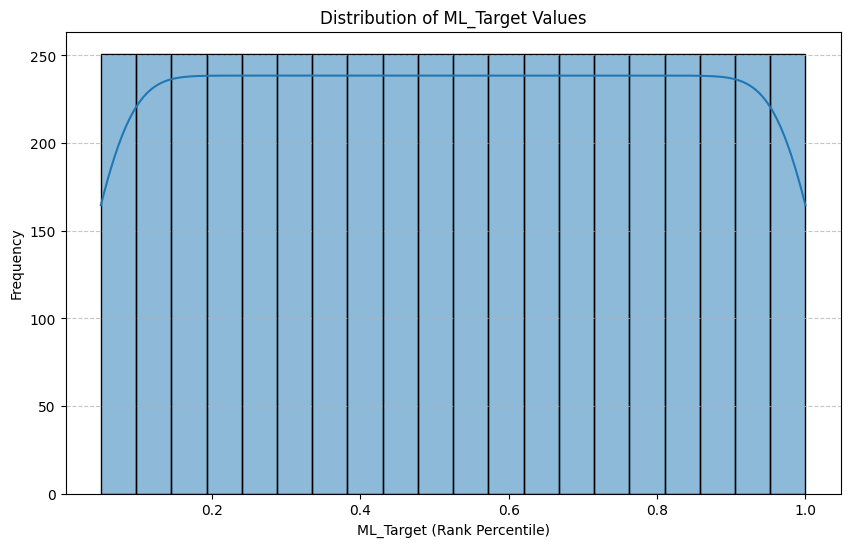

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the distribution of ML_Target values
plt.figure(figsize=(10, 6))
sns.histplot(ml_dataset['ML_Target'], bins=20, kde=True)
plt.title('Distribution of ML_Target Values')
plt.xlabel('ML_Target (Rank Percentile)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

This histogram shows the distribution of the `ML_Target` values. As expected from a rank-normalized variable, the distribution is relatively uniform, meaning that the transformed returns are evenly spread across the 0-1 range. This indicates that the neutralization and rank normalization steps successfully flattened the distribution and reduced the impact of outliers, making the target variable more suitable for machine learning models.

In [19]:
correlation = ml_dataset['Fwd_Return'].corr(ml_dataset['ML_Target'])
print(f"Correlation between Fwd_Return and ML_Target: {correlation:.4f}")

Correlation between Fwd_Return and ML_Target: 0.5363
